In [ ]:
# https://docs.google.com/forms/d/e/1FAIpQLSci4V8kgkj7S33PlRrI7phatjaYnSb7c9qe3Yd092NIW73c1g/viewform?usp=publish-editor
# https://forms.gle/1eNv2wXdbMYjSSaaA

# https://docs.google.com/spreadsheets/d/1hdCBMAIsiq7Y8tMe-Q525zOmgNOU5ER4QImkaDgoDTc/edit?usp=sharing

In [6]:
# URLからQRコードを生成する
import qrcode
from PIL import Image
import pandas as pd
import os

def create_qr_codes_from_excel(excel_path='list.xlsx', output_dir='src/qr', qr_path=None, caption=None):
    """
    ExcelファイルからURLを読み込み、各URLに対してQRコードを生成して保存する
    
    Parameters:
    -----------
    excel_path : str
        Excelファイルのパス
    output_dir : str
        QRコードを保存するディレクトリ
    """
    # 出力ディレクトリが存在しない場合は作成
    os.makedirs(output_dir, exist_ok=True)
    
    if qr_path and caption:
        # QRコードを生成
        qr = qrcode.QRCode(
            version=1,  # QRコードのサイズ (1-40)
            error_correction=qrcode.constants.ERROR_CORRECT_H,  # 高い誤り訂正
            box_size=10,  # 各ボックスのピクセル数
            border=4,  # 境界の幅
        )
        
        qr.add_data(qr_path)
        qr.make(fit=True)
        
        # QRコード画像を作成
        qr_image = qr.make_image(fill_color="black", back_color="white")
        
        # ファイル名を生成（キャプションを使用）
        safe_name = str(caption).replace(' ', '_').replace('/', '_').replace('\\', '_')
        filename = f"{safe_name}.png"
        
        # 保存
        output_path = os.path.join(output_dir, filename)
        qr_image.save(output_path)
        return
    else:
        # Excelファイルを読み込み
        df = pd.read_excel(excel_path)
        
        # URLカラムが存在するか確認
        if 'URL' not in df.columns:
            print("エラー: 'URL'カラムが見つかりません")
            return
        
        # 各行に対してQRコードを生成
        for index, row in df.iterrows():
            url = row['URL']
                    
            # QRコードを生成
            qr = qrcode.QRCode(
                version=1,  # QRコードのサイズ (1-40)
                error_correction=qrcode.constants.ERROR_CORRECT_H,  # 高い誤り訂正
                box_size=10,  # 各ボックスのピクセル数
                border=4,  # 境界の幅
            )
            
            qr.add_data(url)
            qr.make(fit=True)
            
            # QRコード画像を作成
            qr_image = qr.make_image(fill_color="black", back_color="white")
            
            # ファイル名を生成（キャプションを使用）
            if 'キャプション' in df.columns and not pd.isna(row['キャプション']):
                # ファイル名に使えない文字を置換
                safe_name = str(row['キャプション']).replace(' ', '_').replace('/', '_').replace('\\', '_')
                filename = f"{safe_name}.png"
            else:
                filename = f"qr_{index + 1}.png"
            
            # 保存
            output_path = os.path.join(output_dir, filename)
            qr_image.save(output_path)
            return

# 実行例
create_qr_codes_from_excel()


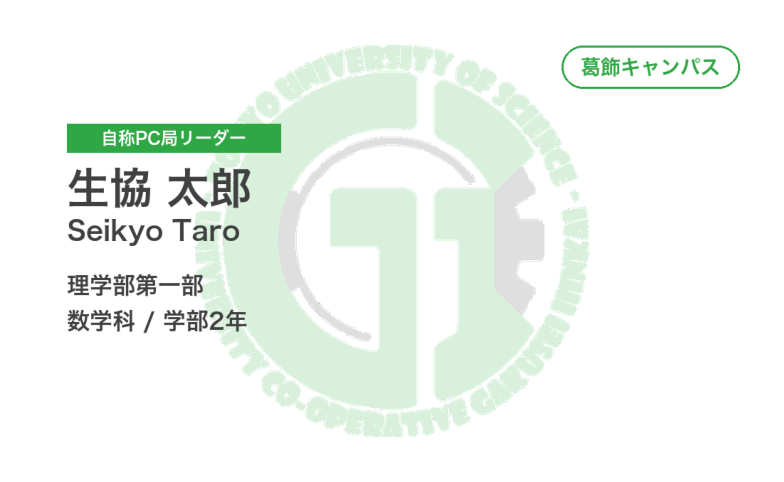

In [10]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageOps
import numpy as np
import pandas as pd

def create_design_preview(logo_path, name_jp, name_en, faculty, department, grade, role, message, message2, campus, url, caption):
    # --- 設定値 ---
    # 名刺サイズ (91mm x 55mm) を高解像度で作成 (300dpi想定: 1075x650 px)
    width, height = 1075, 650

    # カラー定義
    # 各キャンパスのロゴから抽出した色
    tus_katsushika = (46, 167, 68)      # 葛飾キャンパス: グリーン
    tus_noda = (243, 152, 0)            # 野田キャンパス: オレンジ
    tus_kagurazaka = (0, 160, 193)      # 神楽坂キャンパス: シアン
    tus_freshman = (101, 5, 42)         # 新入生: えんじ色
    
    # campusに合わせてtus_colorを選択
    if "葛飾" in campus or "Katsushika" in campus:
        tus_color = tus_katsushika
    elif "野田" in campus or "Noda" in campus:
        tus_color = tus_noda
    elif "神楽坂" in campus or "Kagurazaka" in campus:
        tus_color = tus_kagurazaka
    else:
        tus_color = tus_freshman  # デフォルト
    
    dark_gray = (64, 64, 64)
    white = (255, 255, 255)

    # キャンバス作成 (白背景)
    canvas = Image.new('RGBA', (width, height), white)
    draw = ImageDraw.Draw(canvas)

    # --- フォント設定 ---
    try:
        # macOSの日本語フォントを使用 (ヒラギノ角ゴシック W6 = 太字)
        font_large = ImageFont.truetype("/System/Library/Fonts/ヒラギノ角ゴシック W6.ttc", 60)  # 氏名用
        font_medium = ImageFont.truetype("/System/Library/Fonts/ヒラギノ角ゴシック W6.ttc", 32)  # 学部・学科用
        font_small = ImageFont.truetype("/System/Library/Fonts/ヒラギノ角ゴシック W6.ttc", 24)  # 役職・メッセージ用
        font_tag = ImageFont.truetype("/System/Library/Fonts/ヒラギノ角ゴシック W6.ttc", 28)  # キャンパスタグ用
        font_english_name = ImageFont.truetype("/System/Library/Fonts/ヒラギノ角ゴシック W6.ttc", 38)  # 英名用
    except:
        # フォントが見つからない場合はデフォルト
        font_large = ImageFont.load_default()
        font_medium = ImageFont.load_default()
        font_small = ImageFont.load_default()
        font_tag = ImageFont.load_default()
        font_english_name = ImageFont.load_default()

    # NaN値を空文字列に変換
    if pd.isna(role):
        role = ""
    if pd.isna(message):
        message = ""

    # --- 1. ロゴの透かし配置 (Watermark) ---
    try:
        logo = Image.open(logo_path).convert("RGBA")

        # ロゴをキャンバスの高さに合わせてリサイズ (余白を考慮して90%程度)
        # 高品質なリサイズのためにLANCZOSを使用
        logo_h = int(height * 0.85)
        logo_ratio = logo_h / logo.height
        logo_w = int(logo.width * logo_ratio)
        logo = logo.resize((logo_w, logo_h), Image.Resampling.LANCZOS)

        # 透明度調整 (Alpha値を変更)
        # 完全に透明=0, 不透明=255。ここでは 45 に設定
        logo_data = logo.getdata()
        new_data = []
        for item in logo_data:
            # 色情報はそのまま、アルファ値だけ変更
            if item[3] > 0: # もともと透明でない部分のみ
                new_data.append((item[0], item[1], item[2], 45))
            else:
                new_data.append(item)
        logo.putdata(new_data)

        # 中央に配置
        bg_x = (width - logo_w) // 2
        bg_y = (height - logo_h) // 2

        # アルファ合成のために貼り付け
        canvas.alpha_composite(logo, (bg_x, bg_y))

    except Exception as e:
        print(f"Logo load error: {e}")
        # ロゴがない場合のプレビュー用円形
        draw.ellipse((width//2 - 200, height//2 - 200, width//2 + 200, height//2 + 200), fill=(200, 200, 200, 50))

    # --- 2. テキスト配置 ---
    # レイアウト座標 (px単位)
    margin_x = 80

    # 役職 (Committee Role) - 空でない場合のみ表示
    if role:
        role_text = str(role)
        role_box_x1 = margin_x
        role_box_y1 = 160
        role_box_x2 = margin_x + 300
        role_box_y2 = 200
        draw.rectangle([role_box_x1, role_box_y1, role_box_x2, role_box_y2], fill=tus_color)
        
        # テキストの幅を取得して中央揃え
        role_bbox = draw.textbbox((0, 0), role_text, font=font_small)
        role_text_width = role_bbox[2] - role_bbox[0]
        role_text_height = role_bbox[3] - role_bbox[1]
        role_box_width = role_box_x2 - role_box_x1
        role_box_height = role_box_y2 - role_box_y1
        role_text_x = role_box_x1 + (role_box_width - role_text_width) // 2
        role_text_y = role_box_y1 + (role_box_height - role_text_height) // 2
        draw.text((role_text_x, role_text_y), role_text, fill=white, font=font_small)

    # 氏名 (Name) - Big & Bold
    draw.text((margin_x, 220), name_jp, fill=dark_gray, font=font_large)
    
    # 英名 (English Name)
    draw.text((margin_x, 290), name_en, fill=dark_gray, font=font_english_name)

    # 学部・学科 (Dept)
    draw.text((margin_x, 370), faculty, fill=dark_gray, font=font_medium)
    draw.text((margin_x, 420), f"{department} / {grade}", fill=dark_gray, font=font_medium)

    # 一言メッセージ (Message) - Bottom Left - 空でない場合のみ表示
    if message or message2:
        draw.line((margin_x, 520, margin_x + 600, 520), fill=(200,200,200), width=2)
    if message:
        draw.text((margin_x, 530), str(message), fill=dark_gray, font=font_small)
    if message2:
        if message:
            draw.text((margin_x, 565), str(message2), fill=dark_gray, font=font_small)
        else:
            draw.text((margin_x, 530), str(message2), fill=dark_gray, font=font_small)

    # キャンパス (Campus Tag) - Top Right
    if campus in ["葛飾", "野田", "神楽坂"]:
        campus_text = campus+"キャンパス"
    else:
        campus_text = campus
    tag_w, tag_h = 250, 60
    tag_x = width - tag_w - 50
    tag_y = 50

    # 枠線のみのタグデザイン
    draw.rounded_rectangle([tag_x, tag_y, tag_x + tag_w, tag_y + tag_h], radius=30, outline=tus_color, width=3)
    
    # テキストの幅を取得して中央揃え
    campus_bbox = draw.textbbox((0, 0), campus_text, font=font_tag)
    campus_text_width = campus_bbox[2] - campus_bbox[0]
    campus_text_height = campus_bbox[3] - campus_bbox[1]
    campus_text_x = tag_x + (tag_w - campus_text_width) // 2
    campus_text_y = tag_y + (tag_h - campus_text_height) // 2
    draw.text((campus_text_x, campus_text_y), campus_text, fill=tus_color, font=font_tag)

    # QRコード - Bottom Right
    if url and caption and not pd.isna(caption):
        create_qr_codes_from_excel()
        if not os.path.exists(f'src/qr/{caption}.png'):
            raise FileNotFoundError(f"QR code for caption '{caption}' was not generated.")
        qr_size = 130
        qr_x = width - qr_size - 50
        qr_y = height - qr_size - 50

        try:
            qr_image = Image.open(f'src/qr/{caption}.png').convert("RGBA")
            # QRコードをエリアに合わせてリサイズ
            qr_image = qr_image.resize((qr_size, qr_size), Image.Resampling.LANCZOS)
            # QRコードを貼り付け
            canvas.alpha_composite(qr_image, (qr_x, qr_y))
            # キャプションをQRコードの上に描画
            caption_text = str(caption)
            caption_bbox = draw.textbbox((0, 0), caption_text, font=font_small)
            caption_text_width = caption_bbox[2] - caption_bbox[0]
            caption_text_height = caption_bbox[3] - caption_bbox[1]
            caption_x = qr_x + (qr_size - caption_text_width) // 2
            caption_y = qr_y - caption_text_height - 8  # QRコードの上に少し余白を持たせて配置
            draw.text((caption_x, caption_y), caption_text, fill=dark_gray, font=font_small)
        except Exception as e:
            print(f"QR code load error: {e}")

    return canvas

# テスト用プレビュー
img = create_design_preview(
    logo_path='src/C1_葛飾版ロゴ.png',
    name_jp='生協 太郎',
    name_en='Seikyo Taro',
    faculty='理学部第一部',
    department='数学科',
    grade='学部2年',
    role='自称PC局リーダー',
    message="",
    message2="",
    campus='葛飾',
    url = "",
    caption=""
    )

# 表示
plt.figure(figsize=(10, 6))
plt.imshow(np.asarray(img))
plt.axis('off')
plt.show()


In [10]:
# Install missing engine for pandas.read_excel
%pip install openpyxl

import pandas as pd
from PIL import ImageDraw

# Excelファイルを読み込み
df = pd.read_excel('list.xlsx')
print(f"Loaded list.xlsx successfully")

# A4サイズ (210mm x 297mm) を300dpiで設定
a4_width = int(210 * 300 / 25.4)  # 2480 px
a4_height = int(297 * 300 / 25.4)  # 3508 px

# 名刺サイズ
card_width = 1075
card_height = 650

# A4に配置できる名刺の数 (横2枚、縦4枚 = 8枚/ページ)
cards_per_row = 2
cards_per_col = 4
cards_per_page = cards_per_row * cards_per_col

# 余白計算
margin_x = (a4_width - cards_per_row * card_width) // (cards_per_row + 1)
margin_y = (a4_height - cards_per_col * card_height) // (cards_per_col + 1)

# ページ数を計算
total_cards = len(df)
total_pages = (total_cards + cards_per_page - 1) // cards_per_page

print(f"総名刺数: {total_cards}")
print(f"総ページ数: {total_pages}")

# 点線を描画する関数
def draw_dashed_line(draw, start, end, dash_length=20, gap_length=10, color=(150, 150, 150), width=2):
    x1, y1 = start
    x2, y2 = end
    
    # 線の長さと方向を計算
    dx = x2 - x1
    dy = y2 - y1
    length = (dx**2 + dy**2) ** 0.5
    
    if length == 0:
        return
    
    # 単位ベクトル
    ux = dx / length
    uy = dy / length
    
    # 点線を描画
    current_length = 0
    while current_length < length:
        # ダッシュの開始点
        start_x = x1 + ux * current_length
        start_y = y1 + uy * current_length
        
        # ダッシュの終了点
        end_length = min(current_length + dash_length, length)
        end_x = x1 + ux * end_length
        end_y = y1 + uy * end_length
        
        draw.line([(start_x, start_y), (end_x, end_y)], fill=color, width=width)
        
        current_length += dash_length + gap_length

# 各ページを作成
for page_num in range(total_pages):
    # A4キャンバス作成 (白背景)
    a4_canvas = Image.new('RGB', (a4_width, a4_height), (255, 255, 255))
    
    # このページに配置する名刺のインデックス範囲
    start_idx = page_num * cards_per_page
    end_idx = min(start_idx + cards_per_page, total_cards)
    
    # 名刺の配置位置を記録
    card_positions = []
    
    # 名刺を配置
    for i in range(start_idx, end_idx):
        row_data = df.iloc[i]
        
        # ロゴのPathをキャンパスに応じて選択
        campus = row_data['キャンパス']
        if '葛飾' in campus or 'Katsushika' in campus:
            logo_path = 'src/C1_葛飾版ロゴ.png'
        elif '野田' in campus or 'Noda' in campus:
            logo_path = 'src/C2_野田版ロゴ.png'
        elif '神楽坂' in campus or 'Kagurazaka' in campus:
            logo_path = 'src/C3_神楽坂版ロゴ.png'
        else:
            logo_path = 'src/A2_モノクロ版ロゴ.png'  # デフォルト
        
        if row_data['学年'] == 'B1':
            grade = '学部1年'
        elif row_data['学年'] == 'B2':
            grade = '学部2年'
        elif row_data['学年'] == 'B3':
            grade = '学部3年'
        elif row_data['学年'] == 'B4':
            grade = '学部4年'
        elif row_data['学年'] == 'M1':
            grade = '修士1年'
        elif row_data['学年'] == 'M2':
            grade = '修士2年'
        elif row_data['学年'] == 'D1':
            grade = '博士1年'
        elif row_data['学年'] == 'D2':
            grade = '博士2年'
        elif row_data['学年'] == 'D3':
            grade = '博士3年'
        else:
            grade = row_data['学年']

        # 名刺を生成
        card = create_design_preview(
            logo_path = logo_path,
            name_jp = row_data['苗字']+" "+row_data['名前'],
            name_en = row_data['Last Name']+" "+row_data['First Name'],
            faculty = row_data['学部'],
            department = row_data['学科'],
            grade = str(grade),
            role = row_data['役職'],
            message = row_data['ひとこと'],
            message2 = row_data['ひとこと（2行目）'],
            campus = row_data['キャンパス'],
            url = row_data['URL'],
            caption = row_data['キャプション']
        )
        
        # RGB変換
        card_rgb = card.convert('RGB')
        
        # ページ内での位置を計算 (Z字配置)
        card_index = i - start_idx
        row = card_index // cards_per_row
        col = card_index % cards_per_row
        
        # 配置位置計算
        x = margin_x + col * (card_width + margin_x)
        y = margin_y + row * (card_height + margin_y)
        
        # 名刺を貼り付け
        a4_canvas.paste(card_rgb, (x, y))
        
        # 位置を記録（切り取り線用）
        card_positions.append((x, y, x + card_width, y + card_height))
    
    # 切り取り線を描画
    draw = ImageDraw.Draw(a4_canvas)
    dash_color = (150, 150, 150)  # グレー
    
    # 各名刺の周りに切り取り線を描画
    for x1, y1, x2, y2 in card_positions:
        # 上辺
        draw_dashed_line(draw, (x1, y1), (x2, y1), color=dash_color, width=2)
        # 下辺
        draw_dashed_line(draw, (x1, y2), (x2, y2), color=dash_color, width=2)
        # 左辺
        draw_dashed_line(draw, (x1, y1), (x1, y2), color=dash_color, width=2)
        # 右辺
        draw_dashed_line(draw, (x2, y1), (x2, y2), color=dash_color, width=2)
    
    # ページを保存
    output_filename = f'business_cards_page_{page_num + 1}.png'
    a4_canvas.save(output_filename, format='PNG', dpi=(300, 300))
    print(f"保存完了: {output_filename}")

print("すべての名刺シートの作成が完了しました！")



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Loaded list.xlsx successfully
総名刺数: 4
総ページ数: 1
Note: you may need to restart the kernel to use updated packages.
Loaded list.xlsx successfully
総名刺数: 4
総ページ数: 1
保存完了: business_cards_page_1.png
すべての名刺シートの作成が完了しました！
保存完了: business_cards_page_1.png
すべての名刺シートの作成が完了しました！


In [11]:
import pandas as pd
csv_url = "https://docs.google.com/spreadsheets/d/1hdCBMAIsiq7Y8tMe-Q525zOmgNOU5ER4QImkaDgoDTc/export?format=csv"
df = pd.read_csv(csv_url)
print(df.head())

               タイムスタンプ プロジェクトコード  苗字  名前  Last Name First Name キャンパス  学年   学部  \
0  2025/12/04 13:17:41      TEST  山口  莉玖  Yamaguchi       Riku    葛飾  B4  工学部   

      学科   役割               ひとことメッセージ ひとことメッセージ（2行目） URL印字を希望しますか？  \
0  情報工学科  PC局  使用PC: Surface Pro 11th   なんでも相談に乗ります！            はい   

                                         URL    キャプション  
0  https://text.univ.coop/puk/START/rikadai/  新入生応援サイト  
